Pluto radial velocity at day 1000:
7.06e+6 m/day
81.77 m/s
Acceleration: 9.448479e-7 m/s²


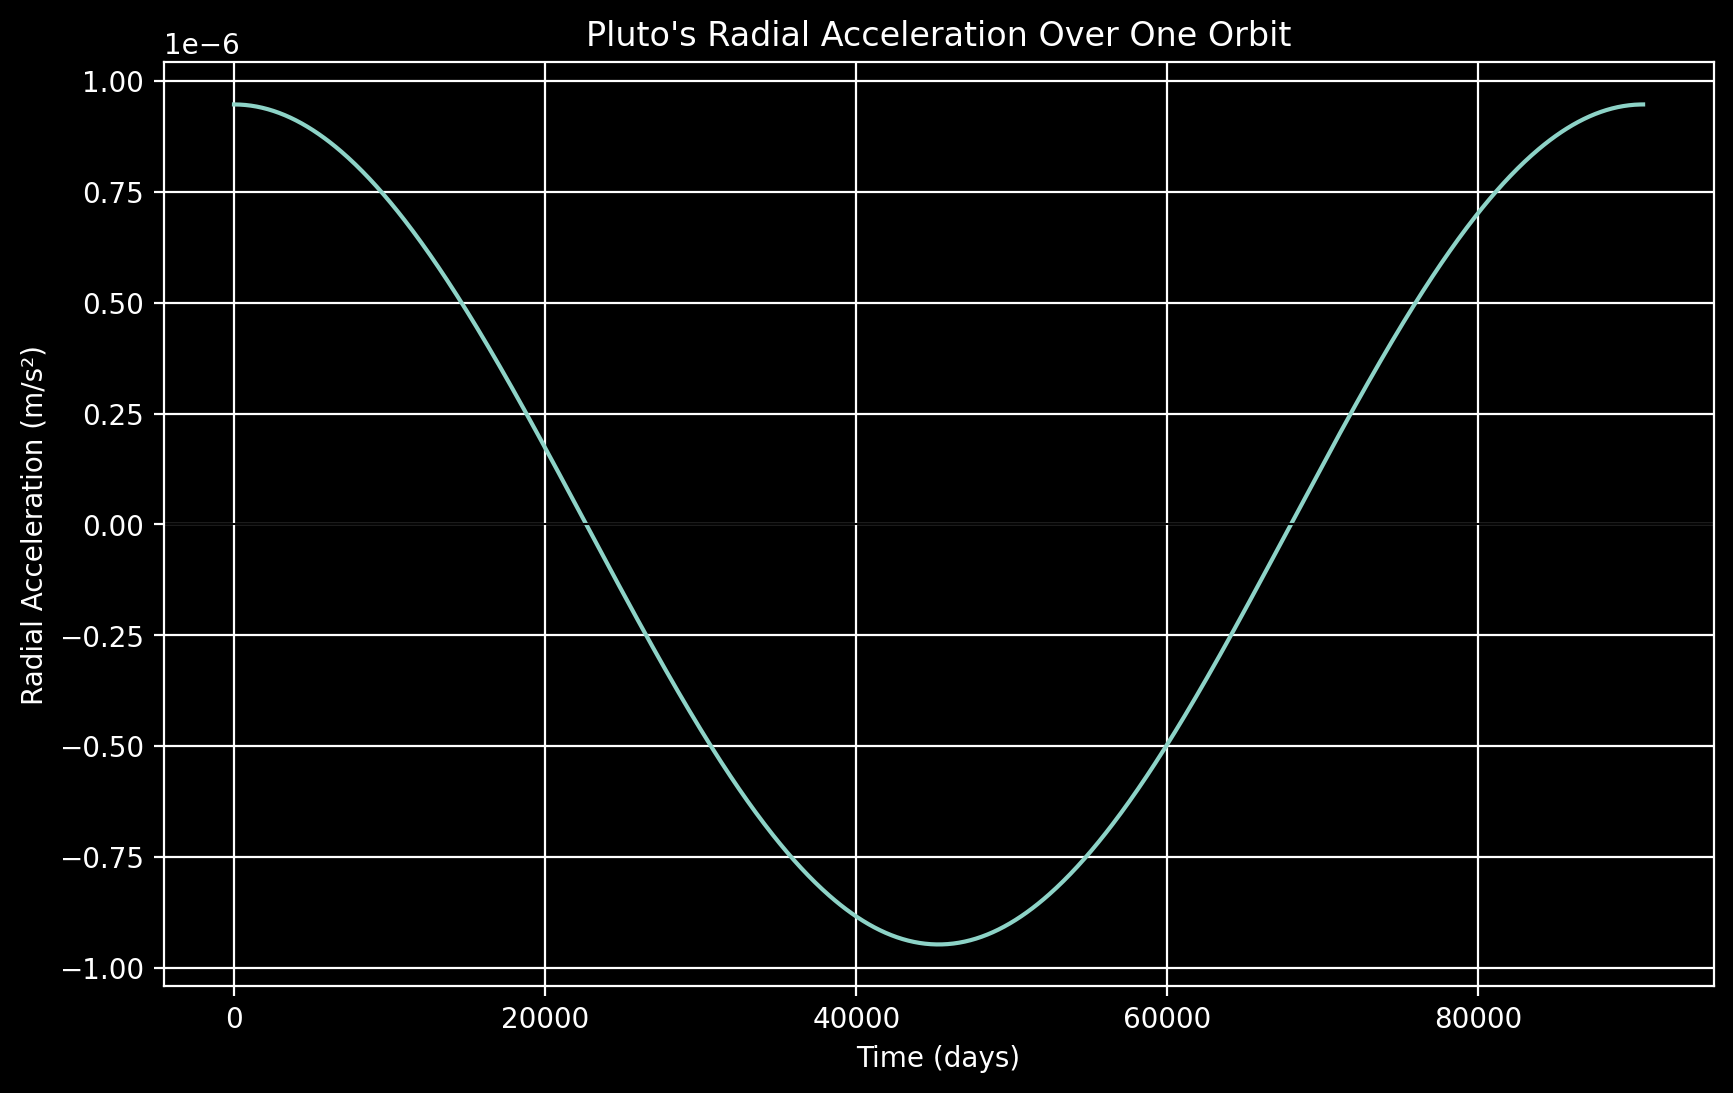

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sympy import symbols, cos, sin, pi, diff, simplify, lambdify

# Step 1: Define symbols
t = symbols('t', real=True)
semi_major_axis = symbols('a', real=True, positive=True)
eccentricity = symbols('e', real=True, positive=True)
omega = symbols('omega', real=True, positive=True)

# Step 2: Define Pluto's orbital radius function
radial_distanceFunc = semi_major_axis * (1 - eccentricity * cos(omega * t))

# Step 3: Differentiate to get radial velocity and acceleration
radial_velocityFunc = simplify(diff(radial_distanceFunc, t))
radial_accelerationFunc = simplify(diff(radial_velocityFunc, t))

# Step 4: Define Pluto's orbital parameters
AU_m = 1.496e11
a_pluto = 39.48 * AU_m
e_pluto = 0.2488
T_pluto_days = 248 * 365.25
omega_pluto = 2 * pi / T_pluto_days
t_eval = 1000  # days

# Step 5: Substitute values
values = {
    semi_major_axis: a_pluto,
    eccentricity: e_pluto,
    omega: omega_pluto,
    t: t_eval
}

# Step 6: Evaluate in m/day, then convert to m/s and m/s²
v_r_m_per_day = radial_velocityFunc.subs(values).evalf()
acceleration_per_day2 = radial_accelerationFunc.subs(values).evalf()

v_r_m_per_sec = v_r_m_per_day / (24 * 3600)
accel_per_sec2 = acceleration_per_day2 / (24 * 3600)**2

# Step 7: Output
print("Pluto radial velocity at day 1000:")
print(f"{v_r_m_per_day:.2e} m/day")
print(f"{v_r_m_per_sec:.2f} m/s")
print(f"Acceleration: {accel_per_sec2:.6e} m/s²")

# Additional Step: Plot radial acceleration over one Pluto orbit
# Create numerical function for acceleration
a_r_func = lambdify(t, radial_accelerationFunc.subs({semi_major_axis: a_pluto, eccentricity: e_pluto, omega: omega_pluto}), 'numpy')

# Generate time values and calculate acceleration
t_vals = np.linspace(0, T_pluto_days, 1000)
acceleration_vals = a_r_func(t_vals) / (24 * 3600)**2

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(t_vals, acceleration_vals)
plt.title("Pluto's Radial Acceleration Over One Orbit")
plt.xlabel("Time (days)")
plt.ylabel("Radial Acceleration (m/s²)")
plt.grid(True)
plt.axhline(0, color='black', linewidth=0.7)
plt.show()

hi


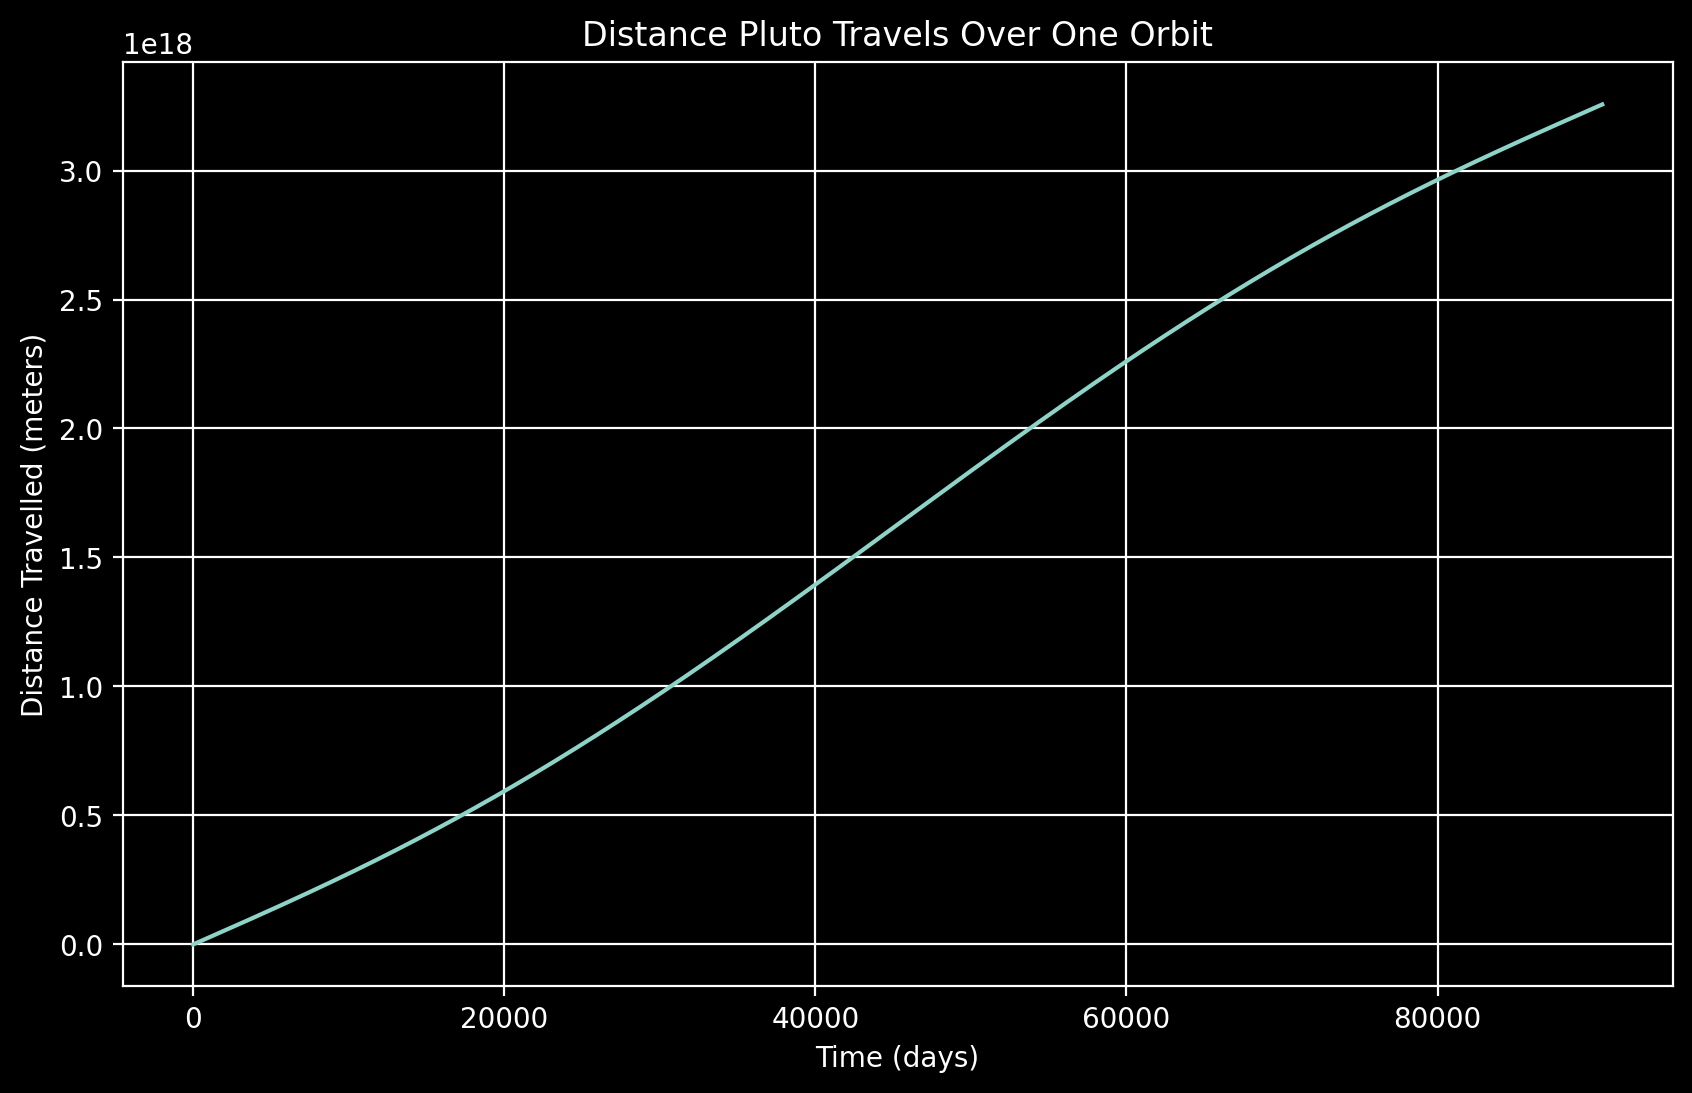

done


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sympy import symbols, cos, sin, pi, diff, simplify, lambdify, sqrt
from scipy.integrate import cumtrapz

# Step 1: Define symbols
t = symbols('t', real=True)
semi_major_axis = symbols('a', real=True, positive=True)
eccentricity = symbols('e', real=True, positive=True)
omega = symbols('omega', real=True, positive=True)

# Step 2: Define Pluto's orbital radius function
radial_distanceFunc = semi_major_axis * (1 - eccentricity * cos(omega * t))

# Step 3: Differentiate to get radial velocity and define orbital speed
radial_velocityFunc = simplify(diff(radial_distanceFunc, t))
orbital_speedFunc = sqrt(radial_velocityFunc**2 + (radial_distanceFunc * omega)**2)

# Step 4: Define Pluto's orbital parameters
AU_m = 1.496e11
a_pluto = 39.48 * AU_m
e_pluto = 0.2488
T_pluto_days = 248 * 365.25
omega_pluto = 2 * pi / T_pluto_days

# Step 5: Create numerical functions for orbital speed
orbital_speed_numeric = lambdify(t, orbital_speedFunc.subs({semi_major_axis: a_pluto, eccentricity: e_pluto, omega: omega_pluto}), 'numpy')

# Step 6: Numerically integrate orbital speed to find cumulative distance travelled over time
t_vals = np.linspace(0, T_pluto_days, 1000)
speed_vals = orbital_speed_numeric(t_vals)
cumulative_distance = cumtrapz(speed_vals, t_vals * 24 * 3600, initial=0)  # convert days to seconds
print('hi')
# Step 7: Plot cumulative distance travelled over one Pluto orbit
plt.figure(figsize=(10, 6))
plt.plot(t_vals, cumulative_distance)
plt.title("Distance Pluto Travels Over One Orbit")
plt.xlabel("Time (days)")
plt.ylabel("Distance Travelled (meters)")
plt.grid(True)
plt.show()
print('done')

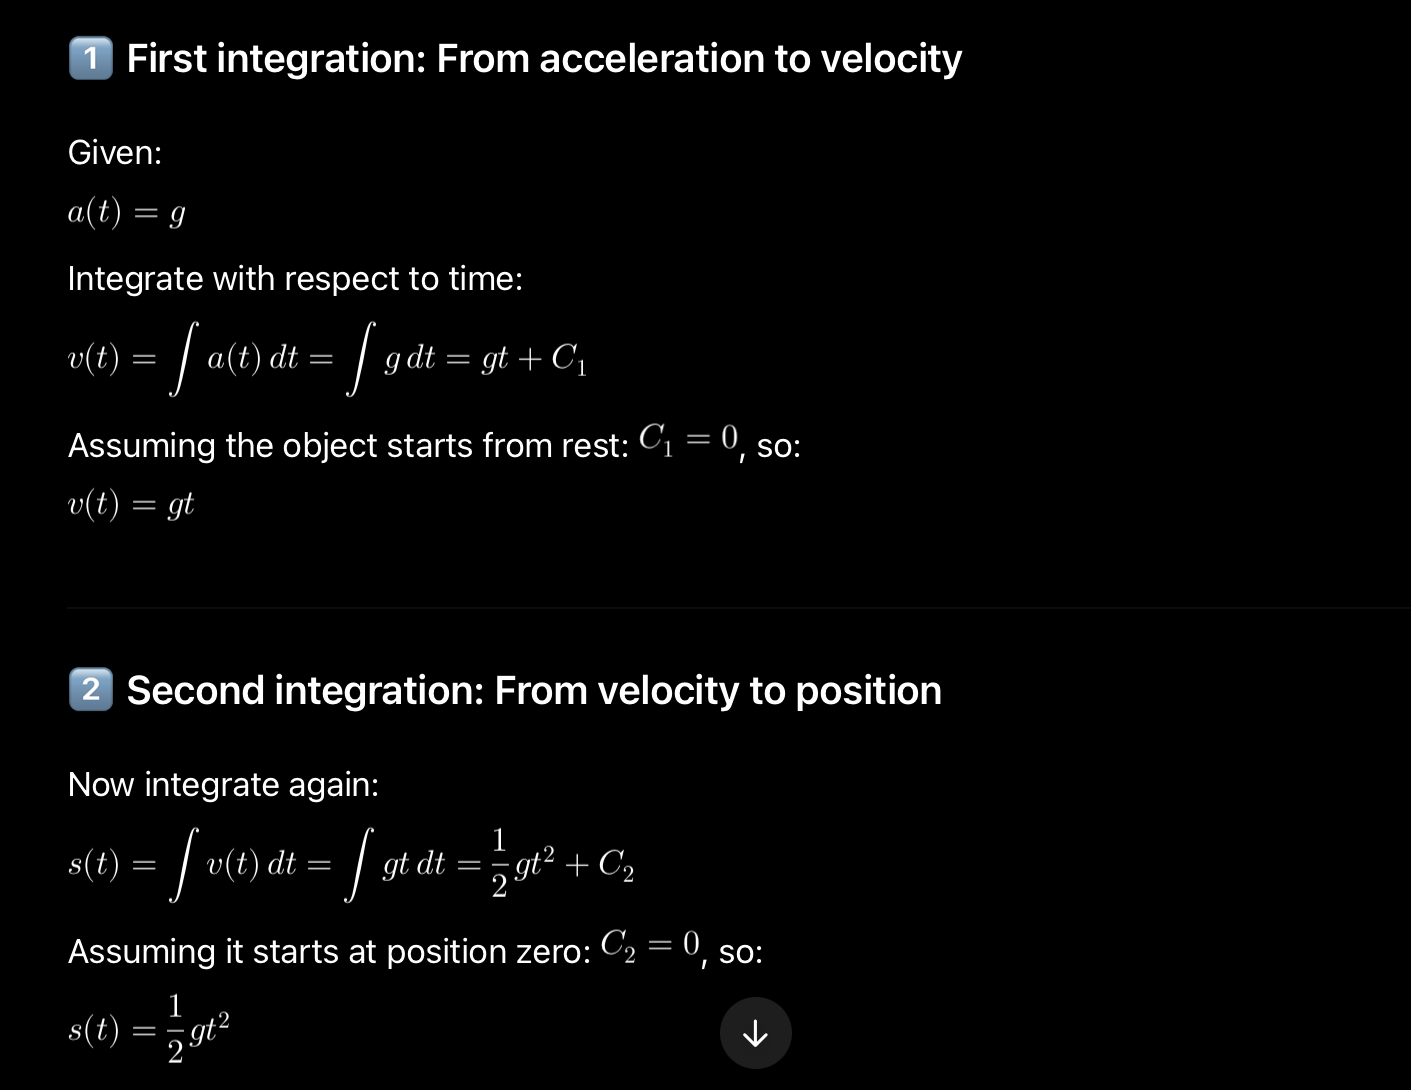

In [2]:
from sympy import symbols, integrate, pprint
from scipy.constants import g  # Earth's gravitational acceleration in m/s²

# Step 1: Define symbolic variable
t = symbols('t', real=True, positive=True)

# Step 2: Define acceleration (a = g)
acceleration = g  # 9.80665 m/s²

# Step 3: Integrate acceleration to get velocity (starting from rest)
velocity_expr = integrate(acceleration, t)  # v(t) = g*t
print(velocity_expr)

# Step 4: Integrate velocity to get position (starting from s = 0)
position_expr = integrate(velocity_expr, t)  # s(t) = (1/2)gt²
print(position_expr)

# Step 5: Evaluate position at t = 100 seconds
position_at_100 = position_expr.subs(t, 100).evalf()

# Output results
print("Position function s(t):")
pprint(position_expr)
print(f"\nDistance covered in 100 seconds at 1G acceleration: {position_at_100:.2f} meters")

9.80665*t
4.903325*t**2
Position function s(t):
          2
4.903325⋅t 

Distance covered in 100 seconds at 1G acceleration: 49033.25 meters
